In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('2015.csv')

display(df.head())
display(df.info())

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

None

### Rename Columns & Check for NaNs

In [2]:
df = df.rename(columns={
    'Economy (GDP per Capita)': 'GDP_per_Capita',
    'Health (Life Expectancy)': 'Life_Expectancy',
    'Trust (Government Corruption)': 'Trust',
    'Happiness Rank': 'Rank',
    'Happiness Score': 'Score'
})

df = df.drop_duplicates()

missing_values = df.isnull().sum().sum()
print(f"Total missing values in dataset: {missing_values}")

Total missing values in dataset: 0


### Visualize Top 5 & Bottom 5 Countries

C:\Users\donga\AppData\Local\Temp\ipykernel_11868\1569040820.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extremes, x='Score', y='Country', palette=['#2ecc71']*5 + ['#e74c3c']*5)


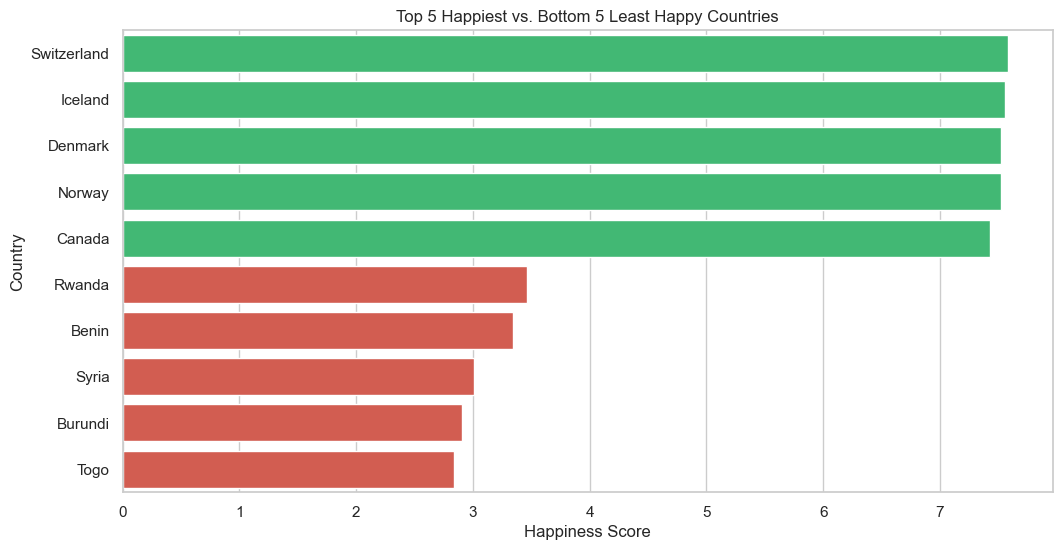

In [4]:
top_5 = df.head(5)
bottom_5 = df.tail(5)

extremes = pd.concat([top_5, bottom_5])

plt.figure(figsize=(12, 6))
sns.barplot(data=extremes, x='Score', y='Country', palette=['#2ecc71']*5 + ['#e74c3c']*5)
plt.title('Top 5 Happiest vs. Bottom 5 Least Happy Countries')
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.show()

### Generate Correlation Heatmap

,Score,GDP_per_Capita,Family,Life_Expectancy,Freedom,Trust,Generosity
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296
std,1.145010,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685
min,2.839000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.526000,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553
50%,5.232500,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130
75%,6.243750,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883
max,7.587000,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880


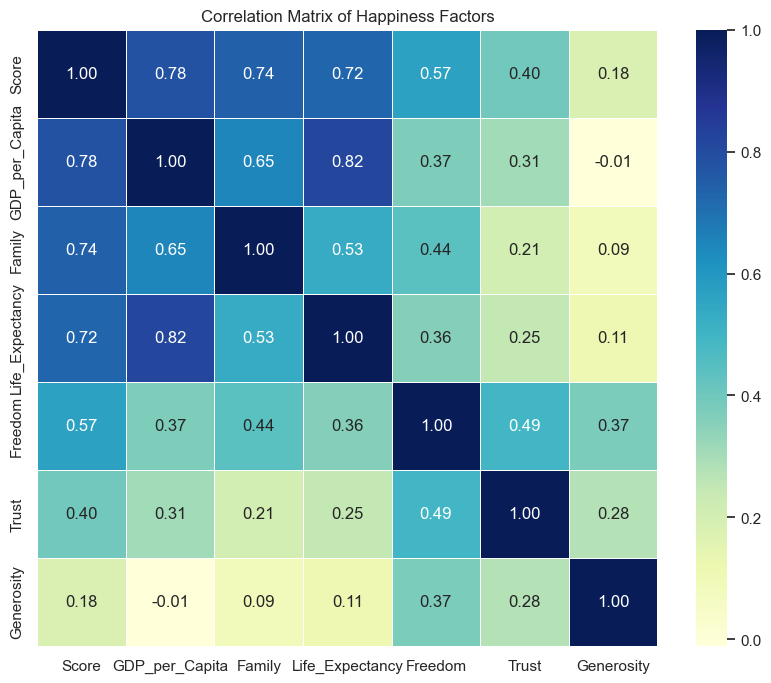

In [3]:
numeric_cols = ['Score', 'GDP_per_Capita', 'Family', 'Life_Expectancy', 'Freedom', 'Trust', 'Generosity']

display(df[numeric_cols].describe())

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Happiness Factors')
plt.show()

### Create Regression Plots (GDP & Life Expectancy)

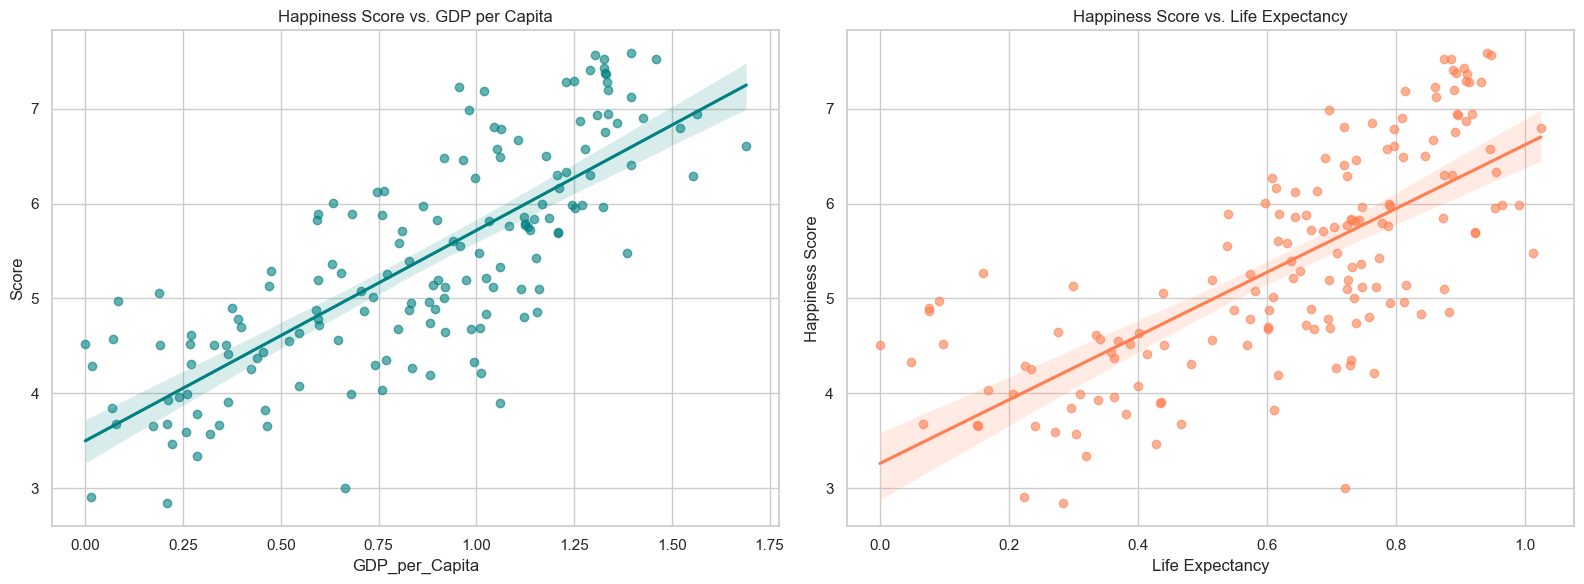

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='GDP_per_Capita', y='Score', ax=axes[0], scatter_kws={'alpha':0.6}, color='teal')
axes[0].set_title('Happiness Score vs. GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

sns.regplot(data=df, x='Life_Expectancy', y='Score', ax=axes[1], scatter_kws={'alpha':0.6}, color='coral')
plt.title('Happiness Score vs. Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Happiness Score')

plt.tight_layout()
plt.show()

### Regional Average Score Visualization

C:\Users\donga\AppData\Local\Temp\ipykernel_11868\4001833675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_score, x='Score', y='Region', palette='viridis')


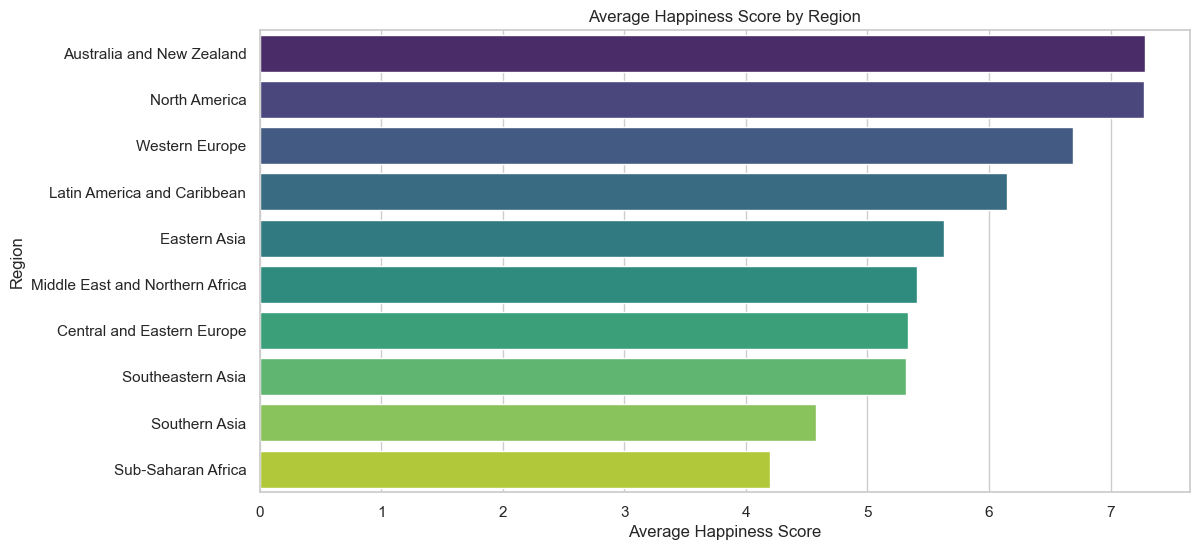

In [10]:
regional_score = df.groupby('Region')['Score'].mean().reset_index()
regional_score = regional_score.sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=regional_score, x='Score', y='Region', palette='viridis')
plt.title('Average Happiness Score by Region')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.show()

### Factor Composition of Happiness Score for Top 5 Countries

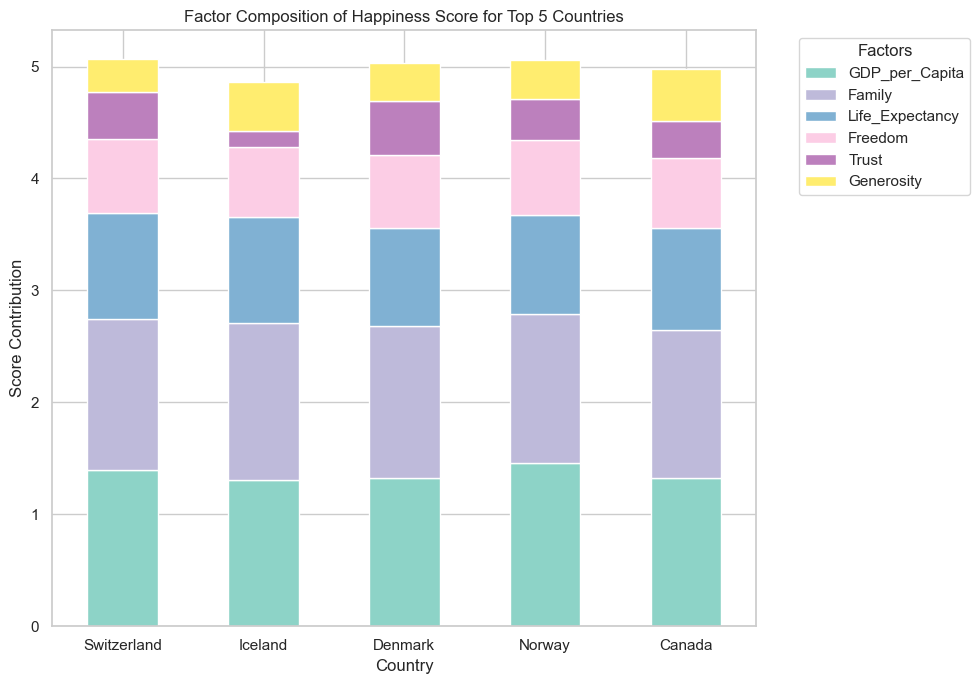

In [11]:
top_5_factors = top_5.set_index('Country')[['GDP_per_Capita', 'Family', 'Life_Expectancy', 'Freedom', 'Trust', 'Generosity']]

top_5_factors.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='Set3')
plt.title('Factor Composition of Happiness Score for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Score Contribution')
plt.legend(title='Factors', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Conclusion and Final Insights

The analysis of the 2015 World Happiness Report yields several clear indicators of global well-being:
* **The Dominance of GDP and Health:** The correlation matrix and scatter plots strongly demonstrate that Economy (GDP per Capita) and Health (Life Expectancy) are the most significant drivers of a country's Happiness Score. 
* **Regional Inequality:** Western Europe and North America consistently dominate the top of the happiness rankings, while regions like Sub-Saharan Africa and Southern Asia are heavily concentrated at the bottom.
* **The Anatomy of a Happy Country:** The stacked bar chart for the top 5 countries (Switzerland, Iceland, Denmark, Norway, Canada) reveals that high overall scores are achieved not just through wealth, but through a balanced combination of strong social support (Family), freedom, and low corruption.